In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/telco_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.shape

(7043, 21)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [17]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [25]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

**Missing Values**

The dataset contains 11 missing values in the TotalCharges column.
These records correspond to customers with zero tenure, indicating newly
joined customers who have not yet accumulated charges.

Because the missing records represent only 0.16% of the dataset, they
were removed during preprocessing.

### EDA Charts

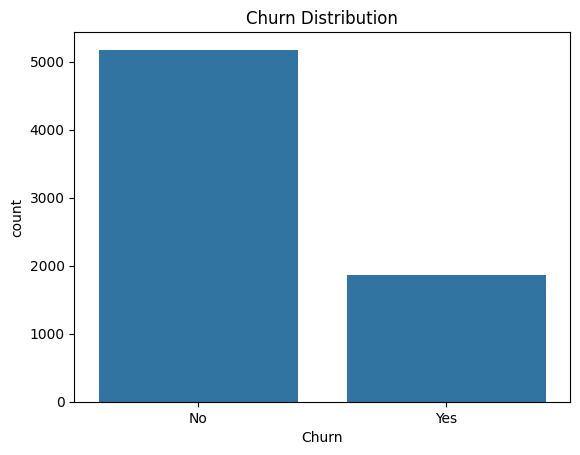

In [27]:
# Churn distribution
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

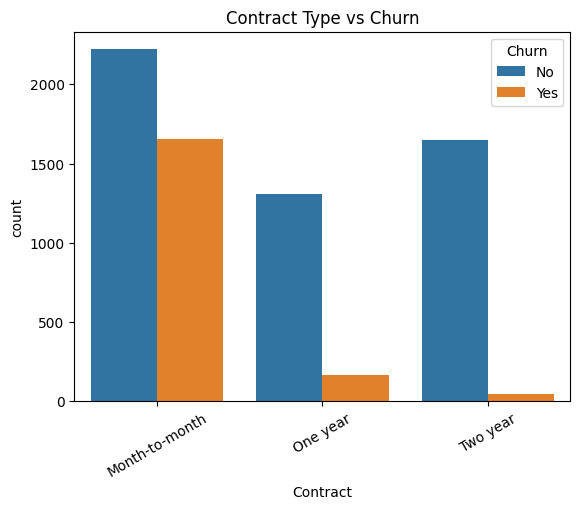

In [28]:
# Contract vs Churn
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.show()

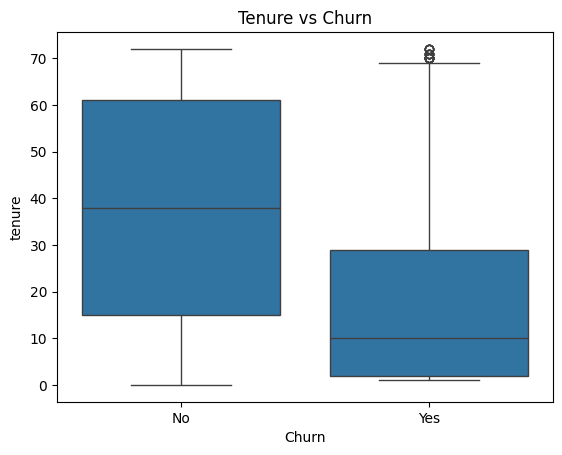

In [29]:
# Tenure vs Churn
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

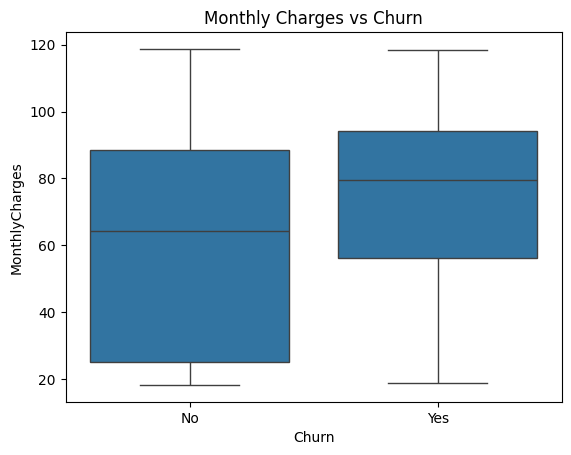

In [30]:
# Monthly Charges vs Churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

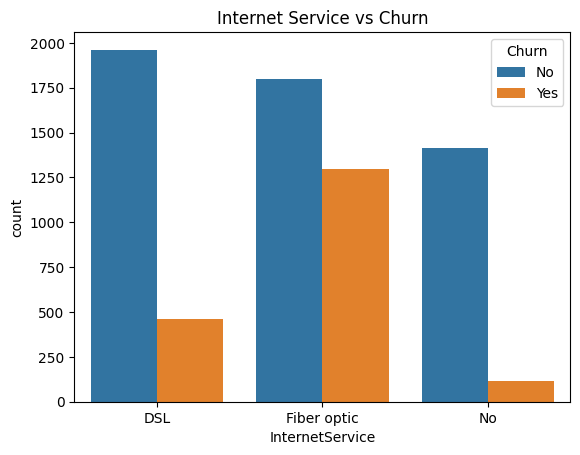

In [31]:
# Internet Service vs Churn
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service vs Churn")
plt.show()

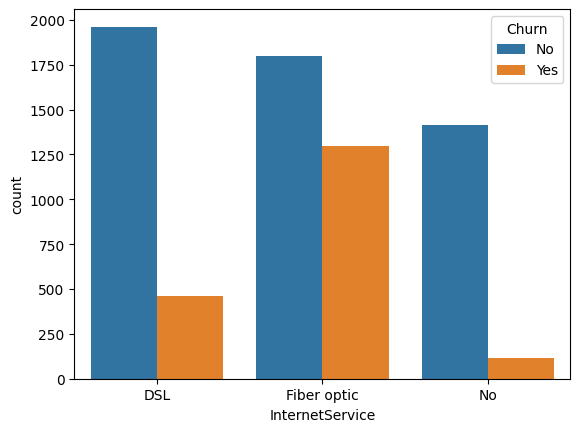

In [33]:
# Internet Service
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)
plt.show()

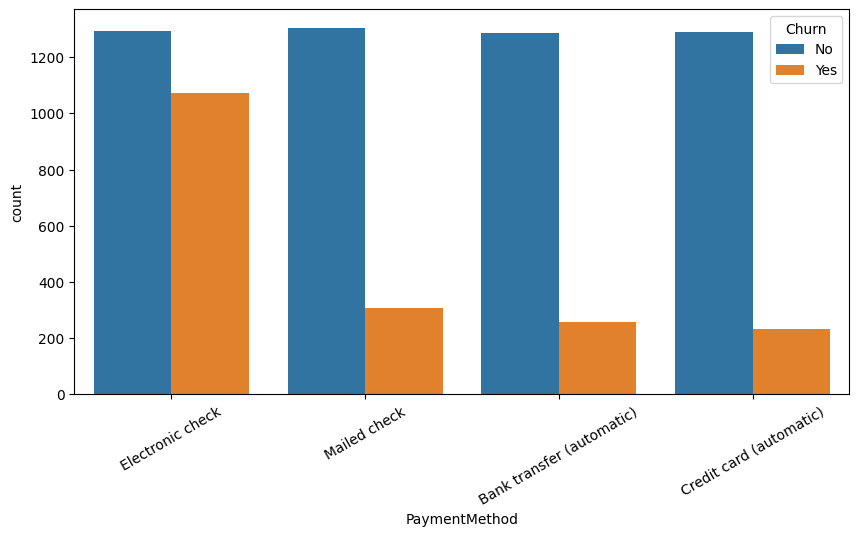

In [34]:
# Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.xticks(rotation=30)
plt.show()

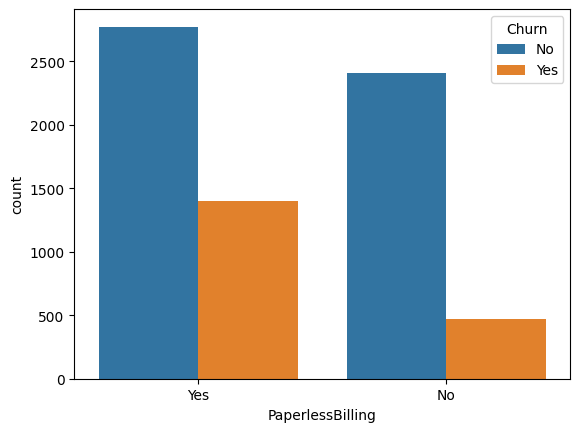

In [35]:
# Paperless Billing
sns.countplot(
    data=df,
    x='PaperlessBilling',
    hue='Churn'
)
plt.show()

In [38]:
df_corr = df.copy()

df_corr = df_corr.drop(columns=["customerID"])

df_corr["Churn"] = df_corr["Churn"].map({
    "No":0,
    "Yes":1
})

df_corr["TotalCharges"] = pd.to_numeric(
    df_corr["TotalCharges"],
    errors="coerce"
)

df_corr = df_corr.dropna()

df_corr = pd.get_dummies(
    df_corr,
    drop_first=True
)

In [39]:
corr = df_corr.corr()["Churn"].sort_values(
    ascending=False
)

corr.head(15)

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService_Yes                  0.011691
gender_Male                      -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
OnlineBackup_Yes                 -0.082307
PaymentMethod_Mailed check       -0.090773
Name: Churn, dtype: float64

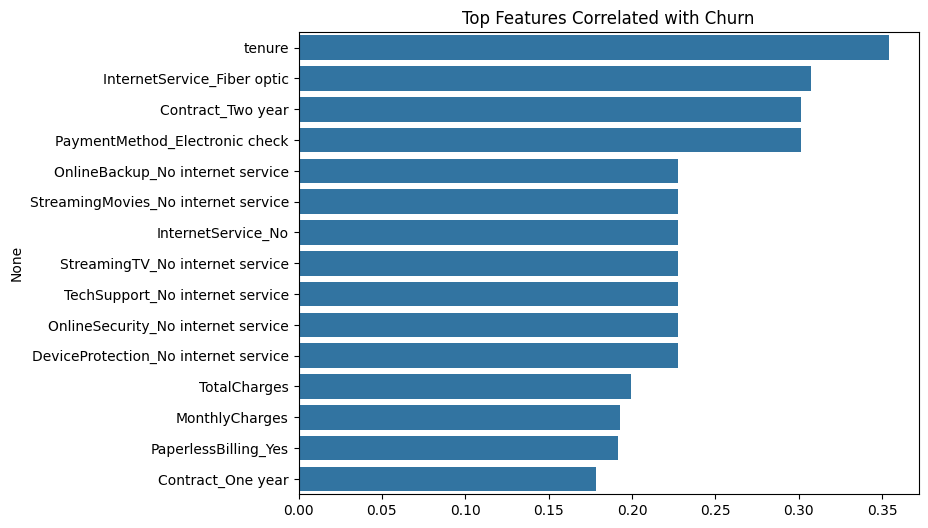

In [40]:
top_corr = corr.drop("Churn").abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Churn")
plt.show()

### EDA Insights
**1: Churn Class Distribution**
* Approximately 27% of customers churned while 73% remained.
* The dataset exhibits moderate class imbalance that should be considered during model evaluation.

**2: Contract Type Strongly Influences Churn**
* Customers on month-to-month contracts show the highest churn rates.
* Customers with one-year and two-year contracts are substantially less likely to churn.

**3: Customer Tenure is a Major Predictor**
* Customers who churn generally have much shorter tenure.
* Long-term customers are significantly more likely to remain with the company.

**4: Higher Monthly Charges Increase Churn Risk**
* Churned customers tend to pay higher monthly charges.
* Pricing and perceived value may influence customer retention.

**5: Fiber Optic Customers Churn More Frequently**
* Fiber optic users show noticeably higher churn rates than DSL users.
* Customers without internet service have the lowest churn rates.

**6: Electronic Check Customers Churn More**
* Customers using electronic checks show significantly higher churn rates.
* Automatic payment methods are associated with better retention.

**7: Paperless Billing is Associated with Higher Churn**
* Customers enrolled in paperless billing appear more likely to churn than customers receiving traditional bills.